In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy
import pandas
import xarray as xr

In [2]:
# Define Directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.5.1/'

In [3]:
# Open File
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open Each File
def Files_Open(Model, Diri, Subset):
    Data_DF = Open_File(Diri+Model+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Model+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Model+'_Codes_Output.csv')
# Edit Time Format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create Phase Distribution Bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [6]:
# Number of Years For Each Climate Scenario
Num_Years = numpy.array([90,93,93])

In [7]:
# Open Files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetB")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetB")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetB")

In [8]:
# Build Phase Space Density
def Build_Phase_Density(x, y, x_Bins, y_Bins):
    x = numpy.array(x)
    y = numpy.array(y)
    Histo, x_Edges, y_Edges = numpy.histogram2d(x, y, bins=[x_Bins, y_Bins])
    Density = Histo.T
    x_Centers = 0.5 * (x_Edges[:-1] + x_Edges[1:])
    y_Centers = 0.5 * (y_Edges[:-1] + y_Edges[1:])
    return (Density, x_Centers, y_Centers)

In [9]:
# Box Filter Smoothing
def Smooth_2D(Box, k):
    if k <= 1:
        return (Box)
    elif k % 2 == 0:
        raise ValueError("k must be odd")
    Pad = k // 2
    x = numpy.pad(Box, ((Pad, Pad), (Pad, Pad)), mode="edge")
    Output = numpy.empty_like(Box, dtype=float)
    for i in range(Output.shape[0]):
        for j in range(Output.shape[1]):
            Output[i, j] = x[i:i+k, j:j+k].mean()
    return (Output)

In [23]:
# Create Function to Calculate Phase Space Distribution
def Phase_Space_Distr(DF, VLT_Bins, B_Bins, VUT_Bins):
# Count Phase Space Distribution
    VLT_B_Count, VLT_Centers, B_Centers = Build_Phase_Density(DF["VLT"], DF["B"], VLT_Bins, B_Bins)
    VLT_VUT_Count, VLT_Centers, VUT_Centers = Build_Phase_Density(DF["VLT"], DF["VUT"], VLT_Bins, VUT_Bins)
#
# Apply Smoothing
    VLT_B_Smooth = Smooth_2D(VLT_B_Count, 7)
    VLT_VUT_Smooth = Smooth_2D(VLT_VUT_Count, 7)
#
# Calculate Phase Space Density
    VLT_B_Density = VLT_B_Smooth / len(DF) * 10000
    VLT_VUT_Density = VLT_VUT_Smooth / len(DF) * 10000
    return (VLT_B_Density, VLT_VUT_Density, VLT_Centers, B_Centers, VUT_Centers)

In [11]:
# Calculate Percentage of Points in Each Quadrant
def Phase_Space_Quadrant(DF, Var):
    if Var == "B":
        DF_Q1 = DF[(DF["VLT"] >= 0) & (DF[Var] > 15)]
        DF_Q2 = DF[(DF["VLT"] < 0) & (DF[Var] > 15)]
        DF_Q3 = DF[(DF["VLT"] < 0) & (DF[Var] <= 15)]
        DF_Q4 = DF[(DF["VLT"] >= 0) & (DF[Var] <= 15)]
    elif Var == "VUT":
        DF_Q1 = DF[(DF["VLT"] >= 0) & (DF[Var] >= 0)]
        DF_Q2 = DF[(DF["VLT"] < 0) & (DF[Var] >= 0)]
        DF_Q3 = DF[(DF["VLT"] < 0) & (DF[Var] < 0)]
        DF_Q4 = DF[(DF["VLT"] >= 0) & (DF[Var] < 0)]
    Q1 = len(DF_Q1) / len(DF)
    Q2 = len(DF_Q2) / len(DF)
    Q3 = len(DF_Q3) / len(DF)
    Q4 = len(DF_Q4) / len(DF)
    return (numpy.array([Q1, Q2, Q3, Q4]))

In [12]:
# Plot Cyclone Phase Distribution
def Phase_Distr_Plot(DF, Model, i, Bounds, Colours, VLT_Bins, B_Bins, VUT_Bins, Colourbar):
# Use Function to Calculate Distributions
    VLT_B, VLT_VUT, VLT_Centers, B_Centers, VUT_Centers = Phase_Space_Distr(DF, VLT_Bins, B_Bins, VUT_Bins)
#
# Build Colour Map
    C_Map = mcolors.ListedColormap(Colours)
    Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='max')
#
# VLT B Distribution
    Axis = Fig.add_subplot(3,2,i*2+1)
    Image = Axis.pcolormesh(VLT_Centers, B_Centers, VLT_B, shading="auto", cmap=C_Map, norm=Norm)
    Phase_Distr_Formatting("B", Model, Axis)
# Add Quadrant Percent
    Quadrant_Percent = Phase_Space_Quadrant(DF, "B")
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2)
#
# VLT VUT Distribution
    Axis = Fig.add_subplot(3,2,i*2+2)
    Image = Axis.pcolormesh(VLT_Centers, VUT_Centers, VLT_VUT, shading="auto", cmap=C_Map, norm=Norm)
    Phase_Distr_Formatting("VUT", Model, Axis)
# Add Quadrant Percent
    Quadrant_Percent = Phase_Space_Quadrant(DF, "VUT")
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2+1)
#
# Colour Bar
    if Colourbar == True:
        Cbar_Label = 'Density (Per 1000 Data Points)'
        Cax = Axis.inset_axes([-0.6, -0.085, 1, 0.03], transform=Axis.transAxes)
        Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax, \
        label=Cbar_Label, ticks=Bounds, shrink=0.7)

In [13]:
# Formatting For Cyclone Phase Distribution Plot
def Phase_Distr_Formatting(y_Var, Model, Axis):
    x_Axis = Create_Bins(-600,600,100)
    pyplot.xlim(-600,600)
    if y_Var == "B":
        y_Axis = Create_Bins(-45,135,15)
        pyplot.ylim(-45,135)
        pyplot.plot([-1000,1000], [15,15], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-150,300], 'black', linewidth=0.5)
    else:
        y_Axis = Create_Bins(-600,600,100)
        pyplot.ylim(-600,600)
        pyplot.plot([-1000,1000], [0,0], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-1000,1000], 'black', linewidth=0.5)
    Axis.set_xticks(x_Axis)
    Axis.set_yticks(y_Axis)
    pyplot.xlabel('VLT', fontsize=12)
    pyplot.ylabel(y_Var, fontsize=12)
    Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
    pyplot.title(Model, fontsize=20)

In [14]:
# Calculate Difference Between Models
def Phase_Space_Diff(Density_1, Density_2):
    Diff = Density_1 - Density_2
# Mask Cells Where Both Scenarios Have Zero Density
    No_Data = (Density_1 == 0) & (Density_2 == 0)
    Diff_Masked = numpy.ma.masked_where(No_Data, Diff)
    return (Diff_Masked)

In [15]:
# Plot Cyclone Phase Distribution Difference
def Phase_Diff_Plot(DF_1, DF_2, Model_1, Model_2, i, Bounds, Colours, VLT_Bins, B_Bins, VUT_Bins, Colourbar):
# Use Function to Calculate Distribution Differences
    VLT_B_1, VLT_VUT_1, VLT_Centers, B_Centers, VUT_Centers = Phase_Space_Distr(DF_1, VLT_Bins, B_Bins, VUT_Bins)
    VLT_B_2, VLT_VUT_2, VLT_Centers, B_Centers, VUT_Centers = Phase_Space_Distr(DF_2, VLT_Bins, B_Bins, VUT_Bins)
    VLT_B_Diff = Phase_Space_Diff(VLT_B_1, VLT_B_2)
    VLT_VUT_Diff = Phase_Space_Diff(VLT_VUT_1, VLT_VUT_2)
#
# Build Colour Map
    C_Map = mcolors.ListedColormap(Colours)
    Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='both')
#
# VLT B Distribution
    Axis = Fig.add_subplot(3,2,i*2+1)
    Image = Axis.pcolormesh(VLT_Centers, B_Centers, VLT_B_Diff, shading="auto", cmap=C_Map, norm=Norm)
    Phase_Diff_Formatting("B", Model_1, Model_2, Axis)
# Add Quadrant Percent
    Quadrant_Percent = Phase_Space_Quadrant(DF_1, "B") - Phase_Space_Quadrant(DF_2, "B")
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2)
#
# VLT VUT Distribution
    Axis = Fig.add_subplot(3,2,i*2+2)
    Image = Axis.pcolormesh(VLT_Centers, VUT_Centers, VLT_VUT_Diff, shading="auto", cmap=C_Map, norm=Norm)
    Phase_Diff_Formatting("VUT", Model_1, Model_2, Axis)
# Add Quadrant Percent
    Quadrant_Percent = Phase_Space_Quadrant(DF_1, "VUT") - Phase_Space_Quadrant(DF_2, "VUT")
    xloc = [0.88,0.12,0.12,0.88]
    yloc = [0.88,0.88,0.12,0.12]
    for q in range(len(Quadrant_Percent)):
        Axis.text(xloc[q], yloc[q], str('%5.3f' % Quadrant_Percent[q]), ha='center', va='center', \
        transform=Axis.transAxes, fontdict={'size':28},color='black')
    Letter_Label(Axis, i*2+1)
#
# Colour Bar
    if Colourbar == True:
        Cbar_Label = 'Density Diff (Per 1000 Data Points)'
        C_Map = mcolors.LinearSegmentedColormap.from_list("Density (10^-3)", Colours, N=len(Colours))
        Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='both')
        Cax = Axis.inset_axes([-0.6, -0.085, 1, 0.03], transform=Axis.transAxes)
        Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax, \
        label=Cbar_Label, ticks=Bounds, shrink=0.7)

In [16]:
# Formatting For Cyclone Phase Difference Plot
def Phase_Diff_Formatting(y_Var, Model_1, Model_2, Axis):
    x_Axis = Create_Bins(-600,600,100)
    pyplot.xlim(-600,600)
    if y_Var == "B":
        y_Axis = Create_Bins(-45,135,15)
        pyplot.ylim(-45,135)
        pyplot.plot([-1000,1000], [15,15], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-150,300], 'black', linewidth=0.5)
    else:
        y_Axis = Create_Bins(-600,600,100)
        pyplot.ylim(-600,600)
        pyplot.plot([-1000,1000], [0,0], 'black', linewidth=0.5)
        pyplot.plot([0,0], [-1000,1000], 'black', linewidth=0.5)
    Axis.set_xticks(x_Axis)
    Axis.set_yticks(y_Axis)
    pyplot.xlabel('VLT', fontsize=12)
    pyplot.ylabel(y_Var, fontsize=12)
    Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
    pyplot.title(str(Model_1 + ' - ' + Model_2), fontsize=20)

In [17]:
# Letter Labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
    Axis.text(0.05, 0.96, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':20},color='black')

In [26]:
# Define Bins
VLT_Bins = Create_Bins(-600,600,20)
B_Bins = Create_Bins(-45,135,2.5)
VUT_Bins = Create_Bins(-600,600,20)

In [50]:
# Define Colours
Distr_Colours = ['white', 'lightskyblue', 'deepskyblue', 'lightseagreen', 'limegreen', 'greenyellow', 'yellow', 'orange', 'red']
Distr_Bounds = numpy.array([0,1e-8,1,2,5,10,20,30,45])
#
# Define Difference Colours
Diff_Colours = ['mediumblue', 'dodgerblue', 'deepskyblue', 'cyan', 'lawngreen', \
'gold', 'orange', 'darkorange', 'red']
Diff_Bounds = numpy.array([-6,-4,-2,-1,1,2,4,6])

In [51]:
# Create Subset of Data: Below 1005hPa
Control_1005hPa = Control_Data[Control_Data["SLP(hPa)"] <= 1005].reset_index()
RCP45_1005hPa = RCP45_Data[RCP45_Data["SLP(hPa)"] <= 1005].reset_index()
RCP85_1005hPa = RCP85_Data[RCP85_Data["SLP(hPa)"] <= 1005].reset_index()

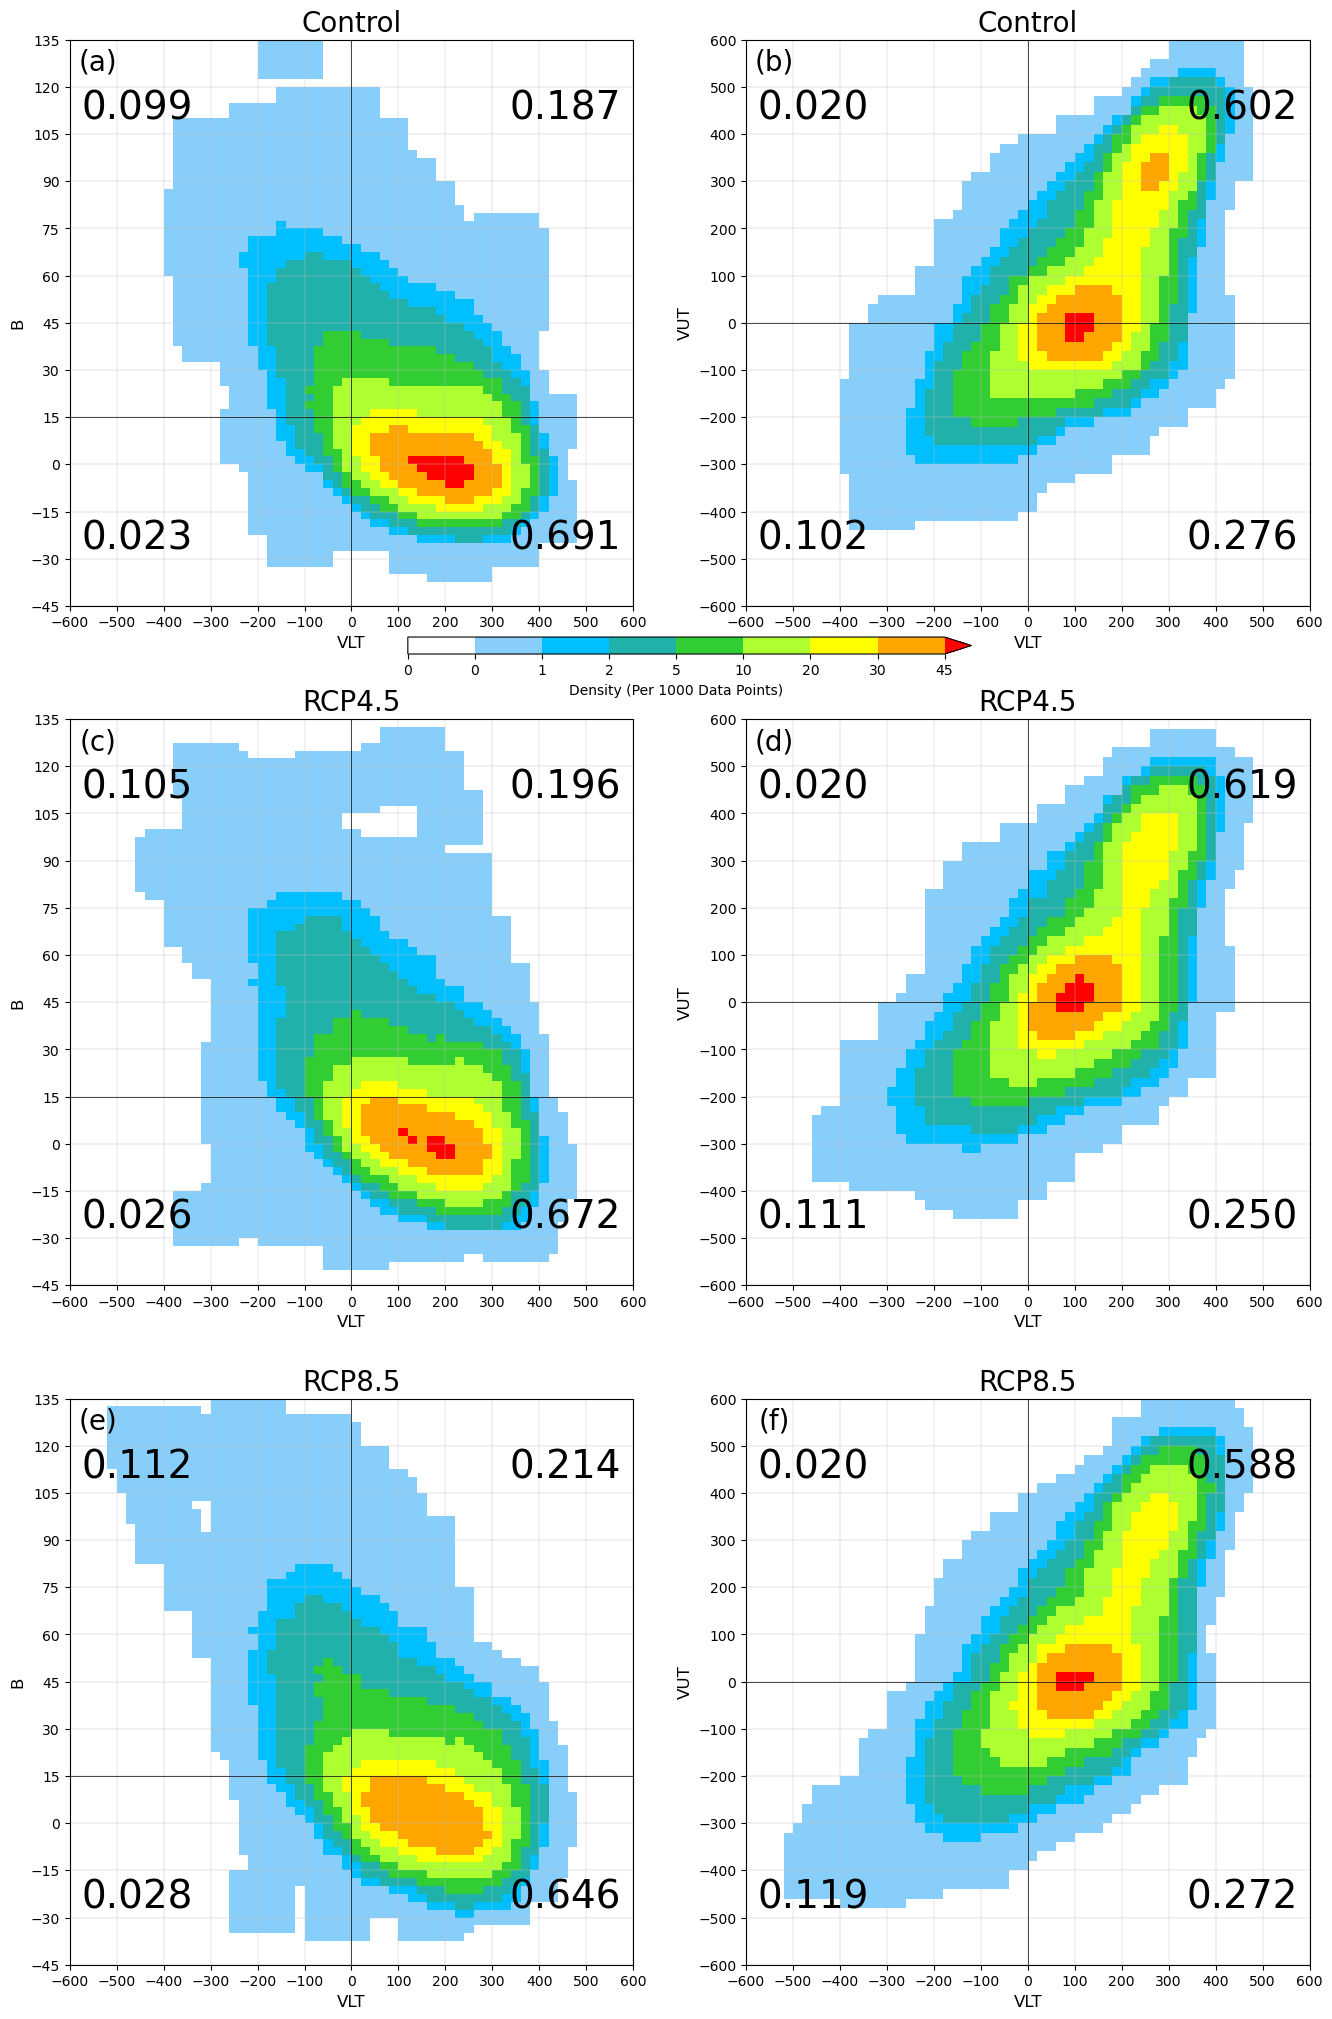

In [52]:
# Figure B10
# Plot Phase Space Distributions
Fig = pyplot.figure(figsize=(16,25))
Phase_Distr_Plot(Control_1005hPa, "Control", 0, Distr_Bounds, Distr_Colours, VLT_Bins, B_Bins, VUT_Bins, True)
Phase_Distr_Plot(RCP45_1005hPa, "RCP4.5", 1, Distr_Bounds, Distr_Colours, VLT_Bins, B_Bins, VUT_Bins, False)
Phase_Distr_Plot(RCP85_1005hPa, "RCP8.5", 2, Distr_Bounds, Distr_Colours, VLT_Bins, B_Bins, VUT_Bins, False)
Fig.savefig(Output_Diri+'Figure_B10.png', bbox_inches='tight')

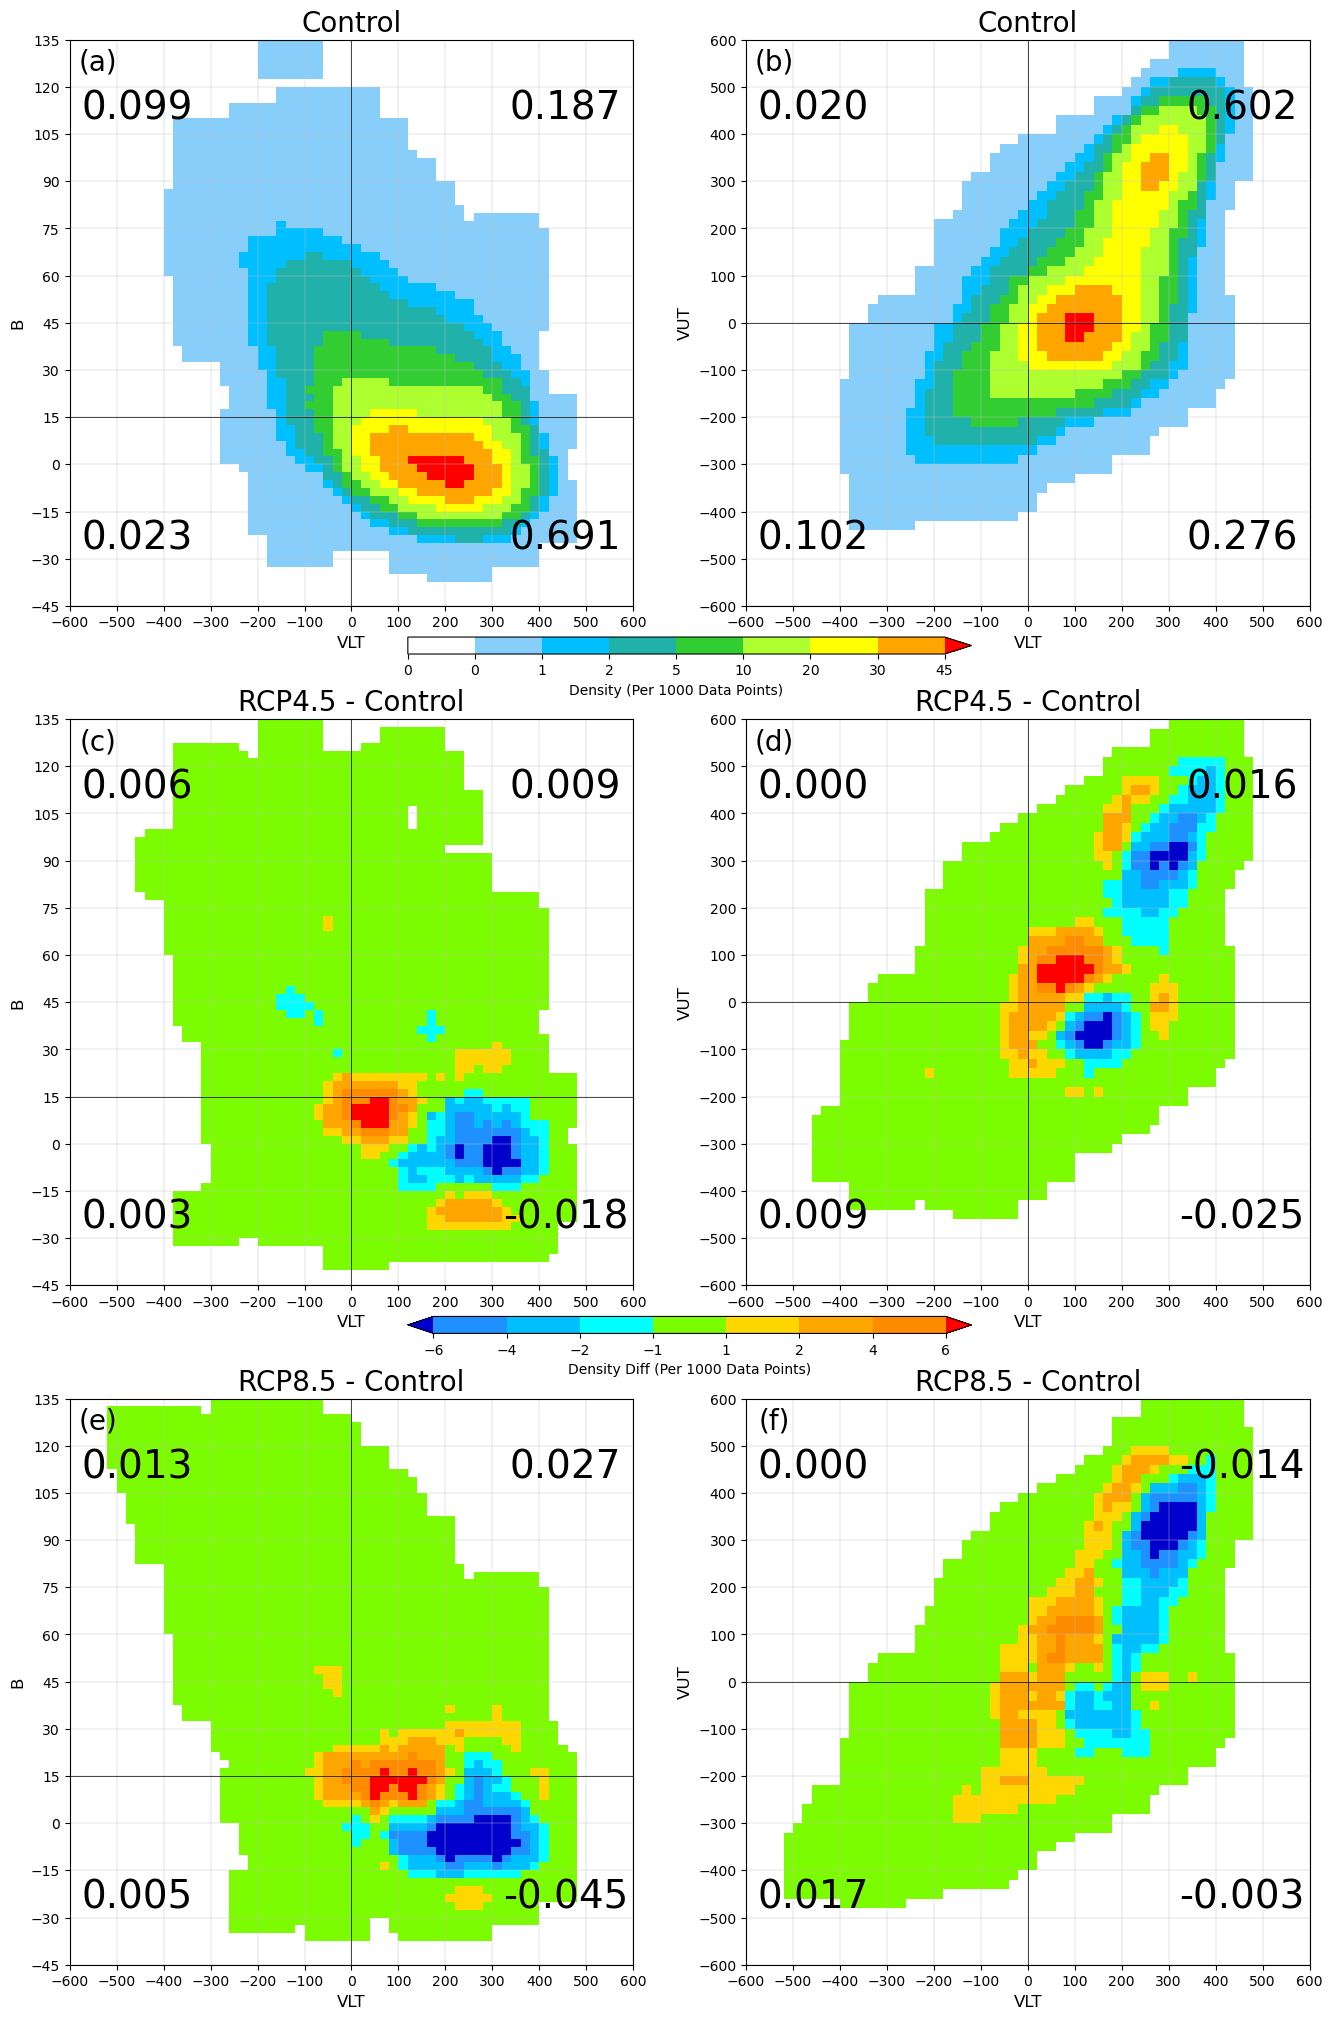

In [53]:
# Figure 10
# Plot Differences Between Phase Space Distributions
Fig = pyplot.figure(figsize=(16,25))
Phase_Distr_Plot(Control_1005hPa, "Control", 0, Distr_Bounds, Distr_Colours, VLT_Bins, B_Bins, VUT_Bins, True)
Phase_Diff_Plot(RCP45_1005hPa, Control_1005hPa, "RCP4.5", "Control", 1, Diff_Bounds, Diff_Colours, VLT_Bins, B_Bins, VUT_Bins, True)
Phase_Diff_Plot(RCP85_1005hPa, Control_1005hPa, "RCP8.5", "Control", 2, Diff_Bounds, Diff_Colours, VLT_Bins, B_Bins, VUT_Bins, False)
Fig.savefig(Output_Diri+'Figure_10.png', bbox_inches='tight')